# Wheat Disease Classification - Deep Learning Pipeline

This notebook mirrors the grape workflow, adapted for wheat disease classes:
- Brown Rust
- Healthy Wheat
- Mildew
- Yellow Rust

Pipeline:
1. Setup and imports
2. Data transforms
3. Dataset split (70/15/15)
4. Class weighting
5. ResNet18 transfer learning
6. Phase-1 training (frozen backbone)
7. Phase-2 fine-tuning
8. Evaluation + confusion matrix
9. Inference helper

## Cell 1: Imports and device

**What:** Import the libraries and select the compute device for training and inference.

**Why:** This initializes the tools and hardware context used by the rest of the notebook.

**Cons:** Environment issues here can block everything that follows.


In [1]:
# Cell 1: Imports and device
import copy
import json
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet18_Weights, resnet18
from torchcam.methods import GradCAMpp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

PyTorch: 2.5.1+cu121
Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU


## Cell 2: Transforms

**What:** Define the image transforms for training and validation.

**Why:** We standardize inputs and add augmentation so the model can generalize better.

**Cons:** Heavy augmentation can sometimes distort important disease patterns.


In [2]:
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

normal_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

heavy_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.RandomPerspective(distortion_scale=0.3, p=0.4),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

print("Transforms ready")

Transforms ready


## Cell 3: Dataset Loading

**What:** Load the crop dataset and split it into train, validation, and test sets.

**Why:** This gives us clean partitions for learning, tuning, and final evaluation.

**Cons:** A random split can still introduce mild class imbalance or sample bias.


In [3]:
DATASET_PATH = "/home/ares/Projects/Agriminds/Dataset/prepro_pbl_dataset/wheat"

full_dataset = ImageFolder(DATASET_PATH)
class_names = full_dataset.classes
NUM_CLASSES = len(class_names)

print(f"Classes ({NUM_CLASSES}): {class_names}")
print(f"Total images: {len(full_dataset)}")

n = len(full_dataset)
n_train = int(0.70 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(42)
)

class WheatDataset(Dataset):
    def __init__(self, subset, class_names, normal_transform, heavy_transform, val_transform, is_train=True):
        self.subset = subset
        self.is_train = is_train
        self.normal_transform = normal_transform
        self.heavy_transform = heavy_transform
        self.val_transform = val_transform
        self.healthy_idx = next((i for i, n in enumerate(class_names) if "healthy" in n.lower()), None)

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if not self.is_train:
            image = self.val_transform(image)
        elif self.healthy_idx is not None and label == self.healthy_idx:
            image = self.heavy_transform(image)
        else:
            image = self.normal_transform(image)
        return image, label

train_data = WheatDataset(train_ds, class_names, normal_transform, heavy_transform, val_transform, is_train=True)
val_data = WheatDataset(val_ds, class_names, normal_transform, heavy_transform, val_transform, is_train=False)
test_data = WheatDataset(test_ds, class_names, normal_transform, heavy_transform, val_transform, is_train=False)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

with open("wheat_classes.json", "w") as f:
    json.dump(class_names, f)

print(f"Split -> Train: {n_train}, Val: {n_val}, Test: {n_test}")
print("DataLoaders ready")

Classes (4): ['Brown Rust', 'Healthy Wheat', 'Mildew', 'Yellow Rust']
Total images: 9417
Split -> Train: 6591, Val: 1412, Test: 1414
DataLoaders ready


## Cell 4: Class Weights

**What:** Compute class weights from the training labels.

**Why:** We reduce bias toward classes with more images during optimization.

**Cons:** If weights are too strong, the model can overcompensate for minority classes.


In [4]:
train_labels = [full_dataset.targets[i] for i in train_ds.indices]
label_counts = Counter(train_labels)

print("Class distribution (train):")
for i, name in enumerate(class_names):
    print(f"  {name}: {label_counts[i]}")

total_train = len(train_labels)
class_weights = torch.tensor(
    [total_train / (NUM_CLASSES * label_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
print("Class-weighted + label-smoothed loss ready")

Class distribution (train):
  Brown Rust: 2325
  Healthy Wheat: 1991
  Mildew: 622
  Yellow Rust: 1653
Class-weighted + label-smoothed loss ready


## Cell 5: ResNet18 Setup

**What:** Load ResNet18 and replace the classifier for the crop disease classes.

**Why:** Transfer learning gives us a strong pretrained backbone with less training time.

**Cons:** A frozen backbone may miss crop-specific visual features at first.


In [5]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for p in model.parameters():
    p.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
for p in model.fc.parameters():
    p.requires_grad = True
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total_params:,}")

print("Model ready")

Trainable: 2,052 / 11,178,564
Model ready


## Cell 6: Augmentation Helpers

**What:** Add mixup, cutmix, and test-time augmentation helper logic.

**Why:** These techniques improve robustness and help the model generalize beyond seen samples.

**Cons:** They add training complexity and can make results harder to interpret.


In [6]:
MIXUP_ALPHA = 0.2
CUTMIX_ALPHA = 1.0
MIXUP_PROB = 0.4
CUTMIX_PROB = 0.3
ENABLE_TTA = True
TTA_MODES = ("none", "hflip", "vflip", "rot90", "rot270")

def _rand_bbox(size, lam):
    h, w = size[2], size[3]
    cut_ratio = np.sqrt(1.0 - lam)
    cut_w = int(w * cut_ratio)
    cut_h = int(h * cut_ratio)
    cx = np.random.randint(w)
    cy = np.random.randint(h)
    x1 = np.clip(cx - cut_w // 2, 0, w)
    y1 = np.clip(cy - cut_h // 2, 0, h)
    x2 = np.clip(cx + cut_w // 2, 0, w)
    y2 = np.clip(cy + cut_h // 2, 0, h)
    return x1, y1, x2, y2

def _apply_mixup(images, labels, alpha):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1.0 - lam) * images[idx]
    return mixed, labels, labels[idx], lam

def _apply_cutmix(images, labels, alpha):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device=images.device)
    labels_a, labels_b = labels, labels[idx]
    x1, y1, x2, y2 = _rand_bbox(images.size(), lam)
    images[:, :, y1:y2, x1:x2] = images[idx, :, y1:y2, x1:x2]
    patch = (x2 - x1) * (y2 - y1)
    lam = 1.0 - patch / float(images.size(-1) * images.size(-2))
    return images, labels_a, labels_b, lam

def _tta_logits(model, images):
    logits = []
    for mode in TTA_MODES:
        if mode == "none":
            aug = images
        elif mode == "hflip":
            aug = torch.flip(images, dims=[3])
        elif mode == "vflip":
            aug = torch.flip(images, dims=[2])
        elif mode == "rot90":
            aug = torch.rot90(images, 1, dims=[2, 3])
        elif mode == "rot270":
            aug = torch.rot90(images, 3, dims=[2, 3])
        else:
            raise ValueError(f"Unknown TTA mode: {mode}")
        logits.append(model(aug))
    return torch.stack(logits, dim=0).mean(dim=0)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        use_mixed = False
        labels_a, labels_b, lam = labels, labels, 1.0
        r = np.random.rand()
        if r < MIXUP_PROB:
            images, labels_a, labels_b, lam = _apply_mixup(images, labels, MIXUP_ALPHA)
            use_mixed = True
        elif r < MIXUP_PROB + CUTMIX_PROB:
            images, labels_a, labels_b, lam = _apply_cutmix(images, labels, CUTMIX_ALPHA)
            use_mixed = True

        outputs = model(images)
        if use_mixed:
            loss = lam * criterion(outputs, labels_a) + (1.0 - lam) * criterion(outputs, labels_b)
        else:
            loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        if use_mixed:
            correct += lam * (preds == labels_a).sum().item() + (1.0 - lam) * (preds == labels_b).sum().item()
        else:
            correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

def run_training_phase(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs,
    patience,
    history,
    phase_tag,
    best_path,
    best_val_so_far,
    save_on_improve=True,
    device='cpu',
):
    local_best_val = best_val_so_far
    patience_count = 0
    epochs_run = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc = eval_epoch(model, val_loader, criterion, device)
        scheduler.step(vl_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        epochs_run += 1
        print(
            f"{phase_tag} Epoch {epoch:02d}/{epochs} | "
            f"Tr Acc: {tr_acc*100:.2f}% | Val Acc: {vl_acc*100:.2f}% | "
            f"Best: {local_best_val*100:.2f}%"
        )

        if vl_acc > local_best_val:
            local_best_val = vl_acc
            patience_count = 0
            if save_on_improve:
                torch.save(model.state_dict(), best_path)
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"Early stopping in {phase_tag}")
                break

    return local_best_val, epochs_run

print("train_epoch, eval_epoch, run_training_phase ready")
print("MixUp/CutMix + TTA configured")

train_epoch, eval_epoch, run_training_phase ready
MixUp/CutMix + TTA configured


## Cell 7: Phase 1 Training (Frozen Base)

**What:** Train phase 1 with the backbone frozen and only the head learning.

**Why:** This safely adapts the classifier before fine-tuning deeper layers.

**Cons:** Accuracy may plateau early because most of the network stays unchanged.


In [7]:
EPOCHS_PHASE1 = 15
PATIENCE_PHASE1 = 3
BEST_MODEL_PATH = "wheat_best_model.pt"

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
phase_boundaries = []
best_val_acc = 0.0

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

best_val_acc, phase1_epochs_run = run_training_phase(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=EPOCHS_PHASE1,
    patience=PATIENCE_PHASE1,
    history=history,
    phase_tag="P1",
    best_path=BEST_MODEL_PATH,
    best_val_so_far=best_val_acc,
    save_on_improve=True,
    device=device,
)

phase_boundaries.append((len(history["train_acc"]) + 0.5, "P1"))
model.load_state_dict(torch.load(BEST_MODEL_PATH, weights_only=True))
print(f"Best validation accuracy after phase 1: {best_val_acc*100:.2f}%")

P1 Epoch 01/15 | Tr Acc: 55.38% | Val Acc: 54.32% | Best: 0.00%
P1 Epoch 02/15 | Tr Acc: 67.72% | Val Acc: 65.79% | Best: 54.32%
P1 Epoch 03/15 | Tr Acc: 68.39% | Val Acc: 64.73% | Best: 65.79%
P1 Epoch 04/15 | Tr Acc: 68.04% | Val Acc: 67.85% | Best: 65.79%
P1 Epoch 05/15 | Tr Acc: 69.12% | Val Acc: 68.70% | Best: 67.85%
P1 Epoch 06/15 | Tr Acc: 70.61% | Val Acc: 71.10% | Best: 68.70%
P1 Epoch 07/15 | Tr Acc: 71.55% | Val Acc: 66.36% | Best: 71.10%
P1 Epoch 08/15 | Tr Acc: 70.46% | Val Acc: 61.54% | Best: 71.10%
P1 Epoch 09/15 | Tr Acc: 70.38% | Val Acc: 72.17% | Best: 71.10%
P1 Epoch 10/15 | Tr Acc: 72.17% | Val Acc: 73.02% | Best: 72.17%
P1 Epoch 11/15 | Tr Acc: 73.03% | Val Acc: 70.75% | Best: 73.02%
P1 Epoch 12/15 | Tr Acc: 71.64% | Val Acc: 70.33% | Best: 73.02%
P1 Epoch 13/15 | Tr Acc: 73.08% | Val Acc: 71.10% | Best: 73.02%
Early stopping in P1
Best validation accuracy after phase 1: 73.02%


## Cell 8: Phase 2 Fine-tuning

**What:** Unfreeze deeper layers and run phase 2 fine-tuning.

**Why:** This lets the pretrained features adapt more closely to crop disease patterns.

**Cons:** Fine-tuning can overfit if the learning rate or patience is not controlled well.


In [8]:
def set_resnet_trainable_layers(model, unfreeze_layer4=True, unfreeze_layer3=False):
    for p in model.parameters():
        p.requires_grad = False
    if unfreeze_layer3:
        for p in model.layer3.parameters():
            p.requires_grad = True
    if unfreeze_layer4:
        for p in model.layer4.parameters():
            p.requires_grad = True
    for p in model.fc.parameters():
        p.requires_grad = True

# Iterative fine-tuning with progressive unfreezing
fine_tune_plan = [
    {"name": "P2A", "layer3": False, "lr": 1e-5, "epochs": 5, "patience": 2},
    {"name": "P2B", "layer3": True, "lr": 5e-6, "epochs": 4, "patience": 2},
]

for stage in fine_tune_plan:
    scope = "layer4+fc" if not stage["layer3"] else "layer3+layer4+fc"
    print(
        f"\nStarting {stage['name']} | unfreeze {scope} | "
        f"lr={stage['lr']} | epochs={stage['epochs']}"
    )

    set_resnet_trainable_layers(
        model,
        unfreeze_layer4=True,
        unfreeze_layer3=stage["layer3"],
    )

    optimizer_stage = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=stage["lr"])
    scheduler_stage = optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage, patience=1)

    best_val_acc, epochs_run = run_training_phase(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer_stage,
        scheduler=scheduler_stage,
        epochs=stage["epochs"],
        patience=stage["patience"],
        history=history,
        phase_tag=stage["name"],
        best_path=BEST_MODEL_PATH,
        best_val_so_far=best_val_acc,
        save_on_improve=True,
        device=device,
    )

    phase_boundaries.append((len(history["train_acc"]) + 0.5, stage["name"]))
    model.load_state_dict(torch.load(BEST_MODEL_PATH, weights_only=True))

torch.save(model.state_dict(), "wheat_final_model.pt")
print(f"Best validation accuracy after iterative fine-tuning: {best_val_acc*100:.2f}%")
print("Saved final model to wheat_final_model.pt")


Starting P2A | unfreeze layer4+fc | lr=1e-05 | epochs=5
P2A Epoch 01/5 | Tr Acc: 72.29% | Val Acc: 76.63% | Best: 73.02%
P2A Epoch 02/5 | Tr Acc: 76.98% | Val Acc: 78.75% | Best: 76.63%
P2A Epoch 03/5 | Tr Acc: 75.99% | Val Acc: 80.38% | Best: 78.75%
P2A Epoch 04/5 | Tr Acc: 77.34% | Val Acc: 83.00% | Best: 80.38%
P2A Epoch 05/5 | Tr Acc: 77.15% | Val Acc: 81.44% | Best: 83.00%

Starting P2B | unfreeze layer3+layer4+fc | lr=5e-06 | epochs=4
P2B Epoch 01/4 | Tr Acc: 78.52% | Val Acc: 83.99% | Best: 83.00%
P2B Epoch 02/4 | Tr Acc: 78.04% | Val Acc: 82.37% | Best: 83.99%
P2B Epoch 03/4 | Tr Acc: 80.29% | Val Acc: 84.42% | Best: 83.99%
P2B Epoch 04/4 | Tr Acc: 81.98% | Val Acc: 85.27% | Best: 84.42%
Best validation accuracy after iterative fine-tuning: 85.27%
Saved final model to wheat_final_model.pt


## Cell 9: Training Plot

**What:** Plot training and validation accuracy and loss across the training phases.

**Why:** The curves help us quickly judge learning progress and spot instability.

**Cons:** Good curves do not always guarantee the model will generalize on unseen data.


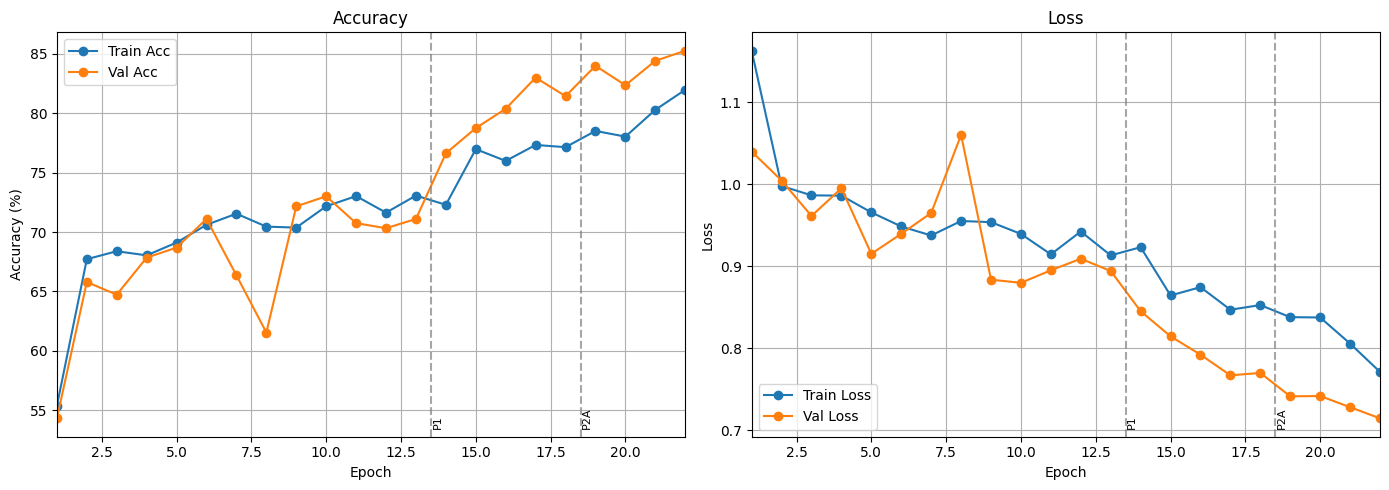

Saved wheat_training_plot.png


In [9]:
all_epochs = list(range(1, len(history["train_acc"]) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(all_epochs, [x * 100 for x in history["train_acc"]], marker="o", label="Train Acc")
ax1.plot(all_epochs, [x * 100 for x in history["val_acc"]], marker="o", label="Val Acc")
valid_boundaries = [(x, tag) for x, tag in phase_boundaries if x < len(all_epochs)]
for x, tag in valid_boundaries:
    ax1.axvline(x=x, color="gray", linestyle="--", alpha=0.7)
ymin1, ymax1 = ax1.get_ylim()
label_y1 = ymin1 + 0.02 * (ymax1 - ymin1)
for x, tag in valid_boundaries:
    ax1.text(x + 0.05, label_y1, tag, rotation=90, va="bottom", fontsize=8, clip_on=True)
ax1.set_xlim(1, len(all_epochs))
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.grid(True)
ax1.legend()

ax2.plot(all_epochs, history["train_loss"], marker="o", label="Train Loss")
ax2.plot(all_epochs, history["val_loss"], marker="o", label="Val Loss")
for x, tag in valid_boundaries:
    ax2.axvline(x=x, color="gray", linestyle="--", alpha=0.7)
ymin2, ymax2 = ax2.get_ylim()
label_y2 = ymin2 + 0.02 * (ymax2 - ymin2)
for x, tag in valid_boundaries:
    ax2.text(x + 0.05, label_y2, tag, rotation=90, va="bottom", fontsize=8, clip_on=True)
ax2.set_xlim(1, len(all_epochs))
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()
print("Saved wheat_training_plot.png")

## Cell 10: Test Evaluation + Confusion Matrix

**What:** Evaluate the trained model on the test set and build a confusion matrix.

**Why:** We measure final performance and see which classes are being confused.

**Cons:** Test metrics summarize outcomes but do not explain the visual reason behind mistakes.


Classification report:
               precision    recall  f1-score   support

   Brown Rust       0.84      0.89      0.86       468
Healthy Wheat       0.97      0.86      0.91       451
       Mildew       0.72      0.89      0.80       126
  Yellow Rust       0.89      0.88      0.89       369

     accuracy                           0.88      1414
    macro avg       0.85      0.88      0.86      1414
 weighted avg       0.88      0.88      0.88      1414



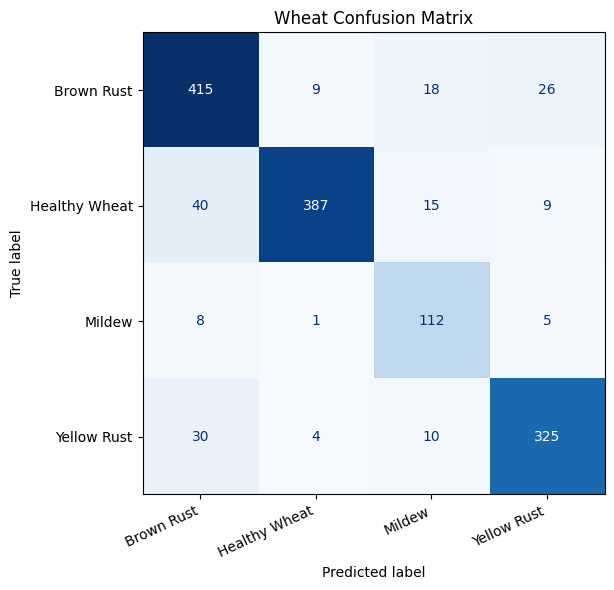

Saved wheat_confusion_matrix.png | TTA=ON


In [10]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        if ENABLE_TTA:
            outputs = _tta_logits(model, images)
        else:
            outputs = model(images)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Classification report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_preds,
    display_labels=class_names,
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Wheat Confusion Matrix")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
print(f"Saved wheat_confusion_matrix.png | TTA={'ON' if ENABLE_TTA else 'OFF'}")

## Cell 11: Explainability and Spread Analysis

**What:** Add leaf segmentation, Grad-CAM, and spread estimation utilities.

**Why:** These steps make predictions more interpretable and estimate how much of the leaf is affected.

**Cons:** Image-processing heuristics can be sensitive to lighting, background, and leaf orientation.


In [11]:
import cv2
import numpy as np
from PIL import Image
import torch
import matplotlib.pyplot as plt
from torchcam.methods import GradCAMpp

# -------------------------------------------------------------
# Utility: remove stale hooks left by interrupted CAM runs
# -------------------------------------------------------------
def _reset_model_hooks(model):
    for m in model.modules():
        if hasattr(m, "_forward_hooks"):
            m._forward_hooks.clear()
        if hasattr(m, "_forward_pre_hooks"):
            m._forward_pre_hooks.clear()
        if hasattr(m, "_backward_hooks"):
            m._backward_hooks.clear()


# -------------------------------------------------------------
# LAYER 1: Leaf Segmentation - GrabCut + HSV fallback chain
# -------------------------------------------------------------
def segment_leaf(image_np):
    h, w = image_np.shape[:2]
    hsv = cv2.cvtColor(image_np, cv2.COLOR_RGB2HSV)
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    # Build a wheat-friendly vegetation prior using hue + ExG.
    mask_green_main = cv2.inRange(hsv, np.array([22, 20, 20]), np.array([95, 255, 255]))
    mask_yellow_green = cv2.inRange(hsv, np.array([16, 15, 25]), np.array([45, 255, 255]))

    bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR).astype(np.int16)
    b = bgr[:, :, 0]
    g = bgr[:, :, 1]
    r = bgr[:, :, 2]
    exg = (2 * g - r - b).astype(np.float32)
    exg_thr = max(10.0, float(np.percentile(exg, 60)))
    exg_mask = exg >= exg_thr

    sat_mask = (s >= 22) & (v >= 20)
    prior = ((mask_green_main > 0) | (mask_yellow_green > 0) | (exg_mask & sat_mask)).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    prior = cv2.morphologyEx(prior, cv2.MORPH_CLOSE, kernel, iterations=2)
    prior = cv2.morphologyEx(prior, cv2.MORPH_OPEN, kernel, iterations=1)

    # Remove tiny background islands from prior.
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(prior, connectivity=8)
    prior_clean = np.zeros_like(prior)
    min_prior_area = max(30, int(0.002 * h * w))
    for lab_idx in range(1, num_labels):
        area = stats[lab_idx, cv2.CC_STAT_AREA]
        if area >= min_prior_area:
            prior_clean[labels == lab_idx] = 255
    prior = prior_clean

    contours, _ = cv2.findContours(prior, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    seg_path = "adaptive"
    if contours and cv2.contourArea(max(contours, key=cv2.contourArea)) > 0.03 * h * w:
        x, y, bw, bh = cv2.boundingRect(max(contours, key=cv2.contourArea))
        pad = 12
        x = max(0, x - pad)
        y = max(0, y - pad)
        bw = min(w - x, bw + 2 * pad)
        bh = min(h - y, bh + 2 * pad)
        rect = (x, y, bw, bh)
    else:
        rect = (28, 28, 168, 168)
        seg_path = "fixed_center"

    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    mask_gc = np.zeros((h, w), np.uint8)
    try:
        cv2.grabCut(image_np, mask_gc, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
        leaf_mask = np.where((mask_gc == 2) | (mask_gc == 0), 0, 255).astype(np.uint8)
    except Exception:
        leaf_mask = prior.copy()
        seg_path = "grabcut_failed_prior"

    # Constrain result with a lightly dilated prior to suppress background bleed.
    prior_dilated = cv2.dilate(prior, kernel, iterations=1)
    leaf_mask = cv2.bitwise_and(leaf_mask, prior_dilated)
    leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    if (leaf_mask > 0).sum() < 0.03 * h * w:
        if (prior > 0).sum() >= 0.01 * h * w:
            leaf_mask = prior
            seg_path = "prior_fallback"
        else:
            leaf_mask = np.full((h, w), 255, np.uint8)
            seg_path = "full_image_uncertain"

    return (leaf_mask > 0), seg_path


# -------------------------------------------------------------
# LAYER 2: GradCAM++ - dynamic target layer selection
# -------------------------------------------------------------
def _resolve_gradcam_target_layer(model):
    if hasattr(model, "features"):
        for idx in range(len(model.features) - 1, -1, -1):
            block = model.features[idx]
            if any(isinstance(m, torch.nn.Conv2d) for m in block.modules()):
                return f"features.{idx}"

    if hasattr(model, "layer4") and hasattr(model.layer4[-1], "conv2"):
        return "layer4.1.conv2"
    if hasattr(model, "layer4"):
        return "layer4"

    last_conv_name = None
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            last_conv_name = name
    if last_conv_name is not None:
        return last_conv_name

    raise ValueError("No Conv2d layer found for Grad-CAM target layer")


def get_gradcam_mask(model, input_tensor, pred_class):
    _reset_model_hooks(model)
    target_layer = _resolve_gradcam_target_layer(model)
    cam_extractor = GradCAMpp(model, target_layer=target_layer)

    was_training = model.training
    prev_requires_grad = [p.requires_grad for p in model.parameters()]

    try:
        model.eval()
        for p in model.parameters():
            p.requires_grad_(True)

        image_batch = input_tensor.unsqueeze(0).to(device)
        image_batch.requires_grad_(True)

        with torch.enable_grad():
            out = model(image_batch)
            cam_map = cam_extractor(int(pred_class), out)[0]

        cam_np = cam_map.detach().squeeze().cpu().numpy()
        cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-8)
        cam_resized = cv2.resize(cam_np, (224, 224), interpolation=cv2.INTER_LINEAR)
        return cam_resized
    finally:
        cam_extractor.remove_hooks()
        for p, req in zip(model.parameters(), prev_requires_grad):
            p.requires_grad_(req)
        model.train(was_training)


# -------------------------------------------------------------
# LAYER 3: Disease Color Detection
# -------------------------------------------------------------
def detect_disease_pixels(image_np, leaf_mask_bin, disease_name):
    # Enhance luminance while preserving chroma for more stable color thresholds.
    lab = cv2.cvtColor(image_np, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    hsv = cv2.cvtColor(enhanced, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)
    l, a, b = cv2.split(lab)

    leaf = leaf_mask_bin.astype(bool)
    if leaf.sum() == 0:
        return np.zeros((image_np.shape[0], image_np.shape[1]), dtype=bool)

    s_leaf = s[leaf]
    v_leaf = v[leaf]
    l_leaf = l[leaf]

    s_p20 = float(np.percentile(s_leaf, 20))
    s_p60 = float(np.percentile(s_leaf, 60))
    v_p30 = float(np.percentile(v_leaf, 30))
    v_p70 = float(np.percentile(v_leaf, 70))
    l_p70 = float(np.percentile(l_leaf, 70))

    brown_mask = (h >= 6) & (h <= 26) & (s >= max(35, s_p20)) & (v >= 35) & (v <= 210)
    yellow_mask = (h >= 16) & (h <= 42) & (s >= max(28, s_p20 - 5)) & (v >= max(85, v_p30))
    dark_necrotic_mask = (v <= max(80, v_p30 - 10)) & (s <= max(115, s_p60 + 5))
    mildew_whitish_mask = (s <= min(65, s_p20 + 20)) & (v >= max(145, v_p70 - 5)) & (l >= max(145, l_p70 - 5))

    disease_name_l = disease_name.lower()
    if "mildew" in disease_name_l:
        disease_mask = mildew_whitish_mask | dark_necrotic_mask
    elif "rust" in disease_name_l:
        disease_mask = brown_mask | yellow_mask | dark_necrotic_mask
    else:
        disease_mask = brown_mask | yellow_mask | dark_necrotic_mask | mildew_whitish_mask

    disease_mask = disease_mask & leaf
    disease_u8 = (disease_mask.astype(np.uint8) * 255)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    disease_u8 = cv2.morphologyEx(disease_u8, cv2.MORPH_OPEN, kernel, iterations=1)
    disease_u8 = cv2.morphologyEx(disease_u8, cv2.MORPH_CLOSE, kernel, iterations=1)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(disease_u8, connectivity=8)
    cleaned = np.zeros_like(disease_u8)
    min_area = max(18, int(0.0012 * leaf.sum()))
    for lab_idx in range(1, num_labels):
        area = stats[lab_idx, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == lab_idx] = 255

    return cleaned > 0


# -------------------------------------------------------------
# FULL PIPELINE
# -------------------------------------------------------------
def calculate_accurate_spread(model, image_path, class_names, val_transform):
    _reset_model_hooks(model)
    original_pil = Image.open(image_path).convert("RGB")
    original_pil = original_pil.resize((224, 224))
    image_np = np.array(original_pil)

    input_tensor = val_transform(original_pil)
    model.eval()
    with torch.no_grad():
        out = model(input_tensor.unsqueeze(0).to(device))
        probs = torch.softmax(out, dim=1)[0]
    pred_class = probs.argmax().item()
    confidence = probs[pred_class].item() * 100
    disease = class_names[pred_class]
    tier = "High" if confidence >= 85 else "Moderate" if confidence >= 70 else "Low"

    if "healthy" in disease.lower():
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.imshow(image_np)
        ax.set_title(f"{disease} | Confidence: {confidence:.1f}% ({tier})")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

        print(f"Disease: {disease} | Confidence: {confidence:.1f}% ({tier})")
        print("Spread: N/A (Healthy plant)")
        return disease, confidence, None, None

    leaf_mask_bin, seg_path = segment_leaf(image_np)
    total_leaf_pixels = int(leaf_mask_bin.sum())
    if total_leaf_pixels == 0:
        leaf_mask_bin = np.ones((224, 224), dtype=bool)
        total_leaf_pixels = int(leaf_mask_bin.sum())
        seg_path = "empty_leaf_fallback"

    erode_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    leaf_core = cv2.erode((leaf_mask_bin.astype(np.uint8) * 255), erode_kernel, iterations=1) > 0
    if leaf_core.sum() < 0.5 * total_leaf_pixels:
        leaf_core = leaf_mask_bin

    cam = get_gradcam_mask(model, input_tensor, pred_class)
    cam_threshold = float(np.percentile(cam, 75))
    cam_bin = cam >= cam_threshold
    cam_support = cam >= float(np.percentile(cam, 55))

    gradcam_coverage = cam_bin.sum() / total_leaf_pixels if total_leaf_pixels > 0 else 0.0
    if gradcam_coverage < 0.01:
        print("Warning: Grad-CAM ROI too small; spread estimate may be unreliable")

    disease_color_mask = detect_disease_pixels(image_np, leaf_core, disease)
    disease_color_mask = disease_color_mask & cam_support

    combined_mask = leaf_core & cam_bin & disease_color_mask
    combined_u8 = (combined_mask.astype(np.uint8) * 255)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(combined_u8, connectivity=8)
    cleaned_combined = np.zeros_like(combined_u8)
    min_combined_area = 10
    for lab_idx in range(1, num_labels):
        area = stats[lab_idx, cv2.CC_STAT_AREA]
        if area >= min_combined_area:
            cleaned_combined[labels == lab_idx] = 255
    combined_mask = cleaned_combined > 0

    diseased_pixels = int(combined_mask.sum())
    spread_percent = (diseased_pixels / total_leaf_pixels) * 100 if total_leaf_pixels > 0 else 0.0

    severity = (
        "Early Stage" if spread_percent < 15 else
        "Moderate" if spread_percent < 40 else "Severe"
    )
    action = (
        "Disease just starting. Apply targeted treatment now." if spread_percent < 15 else
        "Significant spread. Apply fungicide immediately." if spread_percent < 40 else
        "Heavy infection. Isolate crop, consult agronomist."
    )

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    axes[0].imshow(image_np)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(leaf_mask_bin, cmap="Greens")
    axes[1].set_title(f"Leaf Mask ({seg_path})\n{total_leaf_pixels}px")
    axes[1].axis("off")

    axes[2].imshow(cam, cmap="jet")
    axes[2].set_title("GradCAM++ Region")
    axes[2].axis("off")

    axes[3].imshow(disease_color_mask, cmap="Reds")
    axes[3].set_title("Disease Color Pixels")
    axes[3].axis("off")

    overlay = image_np.copy()
    overlay[combined_mask] = [255, 0, 0]
    healthy_leaf = leaf_mask_bin & (~combined_mask)
    overlay[healthy_leaf] = (
        overlay[healthy_leaf] * 0.7 + np.array([0, 200, 0]) * 0.3
    ).astype(np.uint8)

    axes[4].imshow(overlay)
    axes[4].set_title(f"Final: {spread_percent:.1f}% Diseased")
    axes[4].axis("off")

    plt.suptitle(
        f"{disease} | Confidence: {confidence:.1f}% ({tier})\n"
        f"Spread: {spread_percent:.1f}% | {severity}\n{action}\n"
        f"Seg path: {seg_path}",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

    print(f"\n{'=' * 45}")
    print(f"Disease    : {disease}")
    print(f"Confidence : {confidence:.1f}% ({tier})")
    print(f"Seg path   : {seg_path}")
    print(f"Leaf pixels: {total_leaf_pixels}")
    print(f"Diseased px: {diseased_pixels}")
    print(f"Spread     : {spread_percent:.1f}%")
    print(f"Severity   : {severity}")
    print(f"Action     : {action}")
    print(f"{'=' * 45}")

    return disease, confidence, spread_percent, severity

print("Grad-CAM helpers ready")
print("Spread-analysis pipeline ready")

Grad-CAM helpers ready
Spread-analysis pipeline ready


## Cell 12: Self-contained inference runner

**What:** Create a self-contained inference runner for testing a single wheat image end to end.

**Why:** This makes it easy to load the model and generate a prediction without retraining.

**Cons:** Standalone inference code can drift from the training pipeline if updates are not mirrored.


Using test image: /home/ares/Projects/Agriminds/Dataset/prepro_pbl_dataset/wheat/Mildew/mildew_1041.png


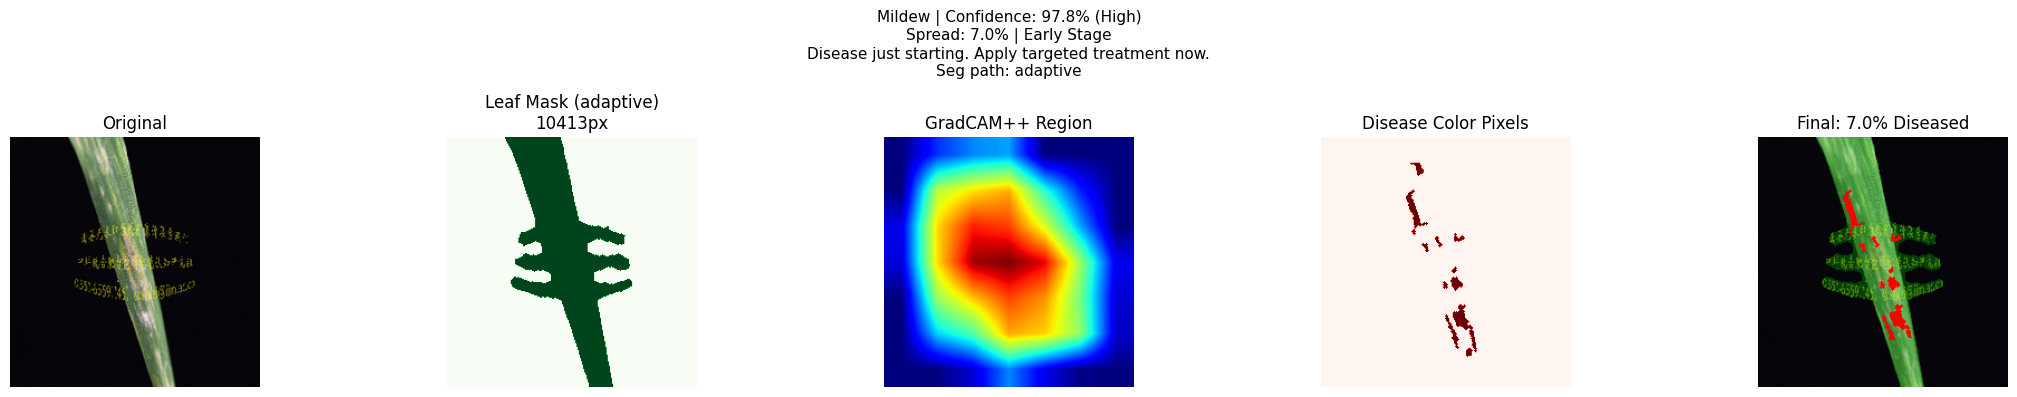


Disease    : Mildew
Confidence : 97.8% (High)
Seg path   : adaptive
Leaf pixels: 10413
Diseased px: 729
Spread     : 7.0%
Severity   : Early Stage
Action     : Disease just starting. Apply targeted treatment now.


In [12]:
# Cell 12: Self-contained inference runner
import json
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision.models import ResNet18_Weights, resnet18

def _ensure_wheat_inference_setup():
    global DATASET_PATH, device, MEAN, STD, val_transform, class_names, model

    if "DATASET_PATH" not in globals():
        DATASET_PATH = "/home/ares/Projects/Agriminds/Dataset/prepro_pbl_dataset/wheat"

    if "device" not in globals():
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if "MEAN" not in globals():
        MEAN = [0.485, 0.456, 0.406]
    if "STD" not in globals():
        STD = [0.229, 0.224, 0.225]
    if "val_transform" not in globals():
        val_transform = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(MEAN, STD),
        ])

    if "class_names" not in globals():
        classes_file = Path("wheat_classes.json")
        if classes_file.exists():
            with classes_file.open("r") as f:
                class_names = json.load(f)
        else:
            class_names = sorted([p.name for p in Path(DATASET_PATH).iterdir() if p.is_dir()])
        print(f"Loaded classes: {class_names}")

    if "model" not in globals():
        model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, len(class_names))

        checkpoint_candidates = [
            "wheat_final_model.pt",
            "wheat_best_model.pt",
            "wheat_phase1.pt",
        ]
        checkpoint = next((p for p in checkpoint_candidates if Path(p).exists()), None)
        if checkpoint is None:
            raise FileNotFoundError("No wheat checkpoint found. Expected one of: wheat_final_model.pt, wheat_best_model.pt, wheat_phase1.pt")

        state = torch.load(checkpoint, map_location=device, weights_only=True)
        model.load_state_dict(state)
        model = model.to(device)
        model.eval()
        print(f"Loaded model from {checkpoint}")

def _basic_predict_with_image(image_path):
    _ensure_wheat_inference_setup()
    original_pil = Image.open(image_path).convert("RGB").resize((224, 224))
    image_np = np.array(original_pil)
    input_tensor = val_transform(original_pil).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out = model(input_tensor)
        probs = torch.softmax(out, dim=1)[0]
    pred_class = int(probs.argmax().item())
    confidence = float(probs[pred_class].item() * 100)
    disease = class_names[pred_class]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(image_np)
    ax.set_title(f"Wheat | {disease} | Confidence: {confidence:.1f}%")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Disease   : {disease}")
    print(f"Confidence: {confidence:.1f}%")
    print("Spread    : N/A (run Cell 11 for Grad-CAM spread pipeline)")
    return disease, confidence, None, None

def _pick_sample_image(dataset_root):
    root = Path(dataset_root)
    sample_candidates = sorted(
        list(root.rglob("*.jpg")) + list(root.rglob("*.jpeg")) + list(root.rglob("*.png"))
    )
    if not sample_candidates:
        raise FileNotFoundError(f"No sample image found inside {root}")
    return str(sample_candidates[0])

def run_wheat_inference(image_path=None):
    _ensure_wheat_inference_setup()

    if image_path is None:
        image_path = _pick_sample_image(DATASET_PATH)

    print(f"Using test image: {image_path}")

    if "calculate_accurate_spread" in globals():
        return calculate_accurate_spread(model, image_path, class_names, val_transform)

    print("Spread helper not loaded yet. Running basic image inference.")
    return _basic_predict_with_image(image_path)



TEST_IMAGE = "/home/ares/Projects/Agriminds/Dataset/prepro_pbl_dataset/wheat/Mildew/mildew_1041.png"
if not Path(TEST_IMAGE).exists():
    TEST_IMAGE = None

disease, confidence, spread_percent, severity = run_wheat_inference(TEST_IMAGE)

## Done

Saved artifacts:
- wheat_phase1.pt
- wheat_best_model.pt
- wheat_final_model.pt
- wheat_training_plot.png
- wheat_confusion_matrix.png
- wheat_classes.json

Using test image: /home/ares/Projects/Agriminds/Dataset/prepro_pbl_dataset/wheat/Mildew/mildew_1043.png


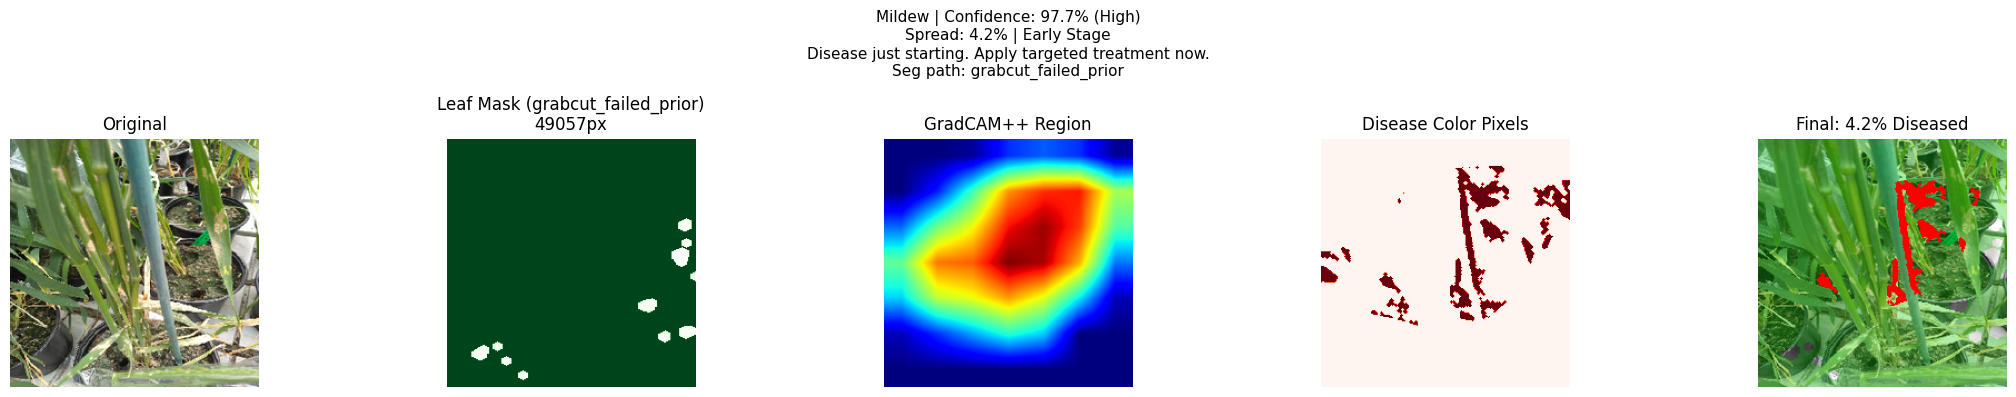


Disease    : Mildew
Confidence : 97.7% (High)
Seg path   : grabcut_failed_prior
Leaf pixels: 49057
Diseased px: 2053
Spread     : 4.2%
Severity   : Early Stage
Action     : Disease just starting. Apply targeted treatment now.


In [13]:
TEST_IMAGE = "/home/ares/Projects/Agriminds/Dataset/prepro_pbl_dataset/wheat/Mildew/mildew_1043.png"
if not Path(TEST_IMAGE).exists():
    TEST_IMAGE = None

disease, confidence, spread_percent, severity = run_wheat_inference(TEST_IMAGE)